In [11]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "decision_trees"

def image_path(fig_id):
    return os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID, fig_id)

def save_fig(fig_id, tight_layout=True):
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(image_path(fig_id) + ".png", format='png', dpi=300)

In [13]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

image_path

iris = load_iris()
X = iris.data[:, 2:] # petal length and width
y = iris.target
tree_clf = DecisionTreeClassifier(max_depth=2)
tree_clf.fit(X, y)

from sklearn.tree import export_graphviz
export_graphviz(
        tree_clf,
        out_file=image_path("iris_tree.png"),
        feature_names=iris.feature_names[2:],
        class_names=iris.target_names,
        rounded=True,
        filled=True
)




In [15]:
!ls

Material_generation.ipynb
Notebooks
data
images


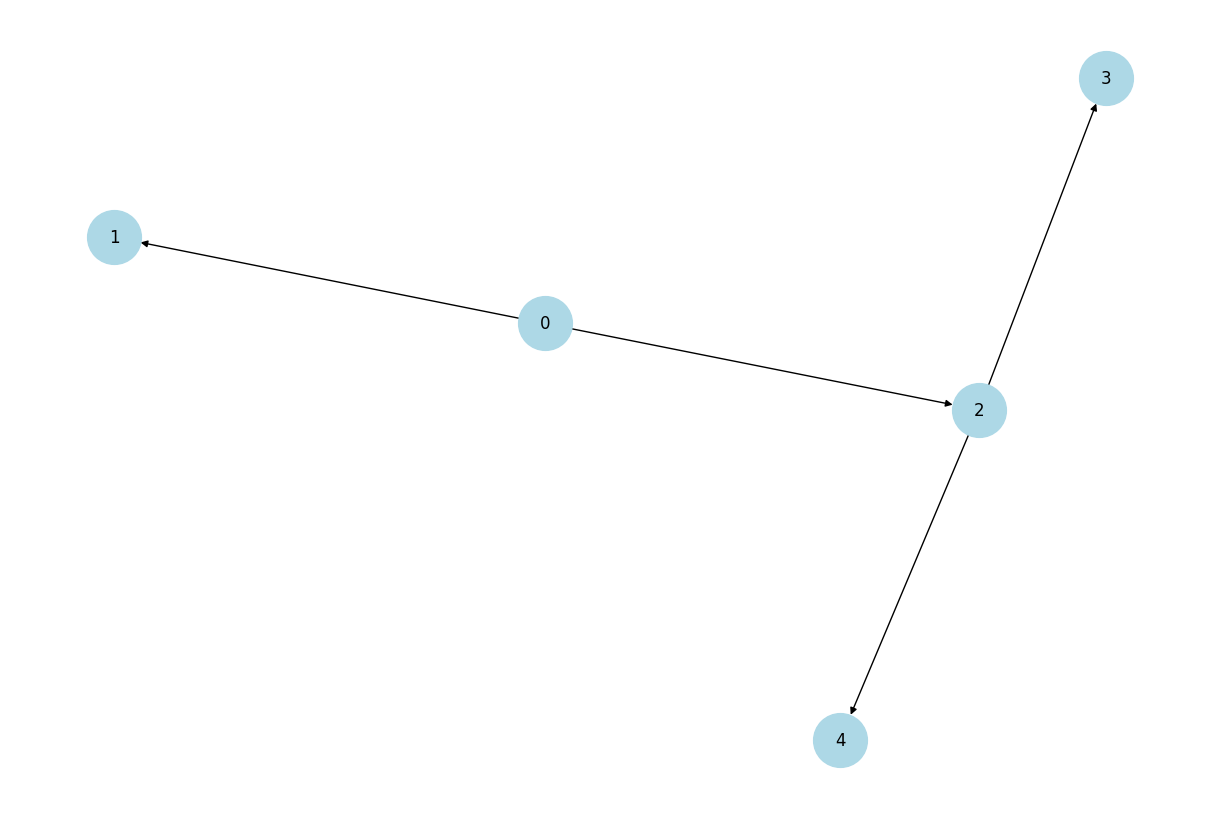

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import read_dot

# Read the DOT file into a NetworkX graph
G = read_dot('images/decision_trees/iris_tree.dot')

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)  # or try nx.dot_layout(G) if available
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=1500, arrows=True)

# Save as PNG
plt.savefig('images/decision_trees/iris_tree.png')